# 03 — Interpretability (SHAP Analysis)
SHAP analysis για XGBoost (κύρια ανάλυση) και FFNN (επιδεικτικός ρόλος).
Στόχος: κατανόηση ποιες μεταβλητές επηρεάζουν τις προβλέψεις.

## 1. Εισαγωγή βιβλιοθηκών

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import os
import glob
import datetime
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from tensorflow import keras
import tensorflow as tf

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Βιβλιοθήκες φορτώθηκαν επιτυχώς.")

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


## 2. Φόρτωση δεδομένων και μοντέλων

In [20]:
DATA_DIR = '../data/processed'

X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_val   = np.load(f'{DATA_DIR}/X_val.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

X_train_scaled = np.load(f'{DATA_DIR}/X_train_scaled.npy')
X_test_scaled  = np.load(f'{DATA_DIR}/X_test_scaled.npy')

feature_names = np.load(f'{DATA_DIR}/feature_names.npy', allow_pickle=True)

print(f"Δεδομένα φορτώθηκαν: {X_test.shape}")
print(f"Features: {len(feature_names)}")

Δεδομένα φορτώθηκαν: (1480, 23)
Features: 23


In [21]:
# Φόρτωση μοντέλων
lr_model  = joblib.load('../data/models/lr_model.pkl')

xgb_model = XGBClassifier()
xgb_model.load_model('../data/models/xgb_model.json')

ffnn_model = keras.models.load_model('../data/models/ffnn_model.keras')

print("Μοντέλα φορτώθηκαν επιτυχώς.")

Μοντέλα φορτώθηκαν επιτυχώς.


## 3. SHAP Analysis — XGBoost
### 3.1 Υπολογισμός SHAP Values

In [22]:
# Δημιουργία SHAP explainer για XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Υπολογισμός SHAP values στο test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values υπολογίστηκαν επιτυχώς.")

SHAP values shape: (1480, 23)
SHAP values υπολογίστηκαν επιτυχώς.


### 3.2 Global Interpretability — Feature Importance
Ποιες μεταβλητές επηρεάζουν περισσότερο το μοντέλο συνολικά;

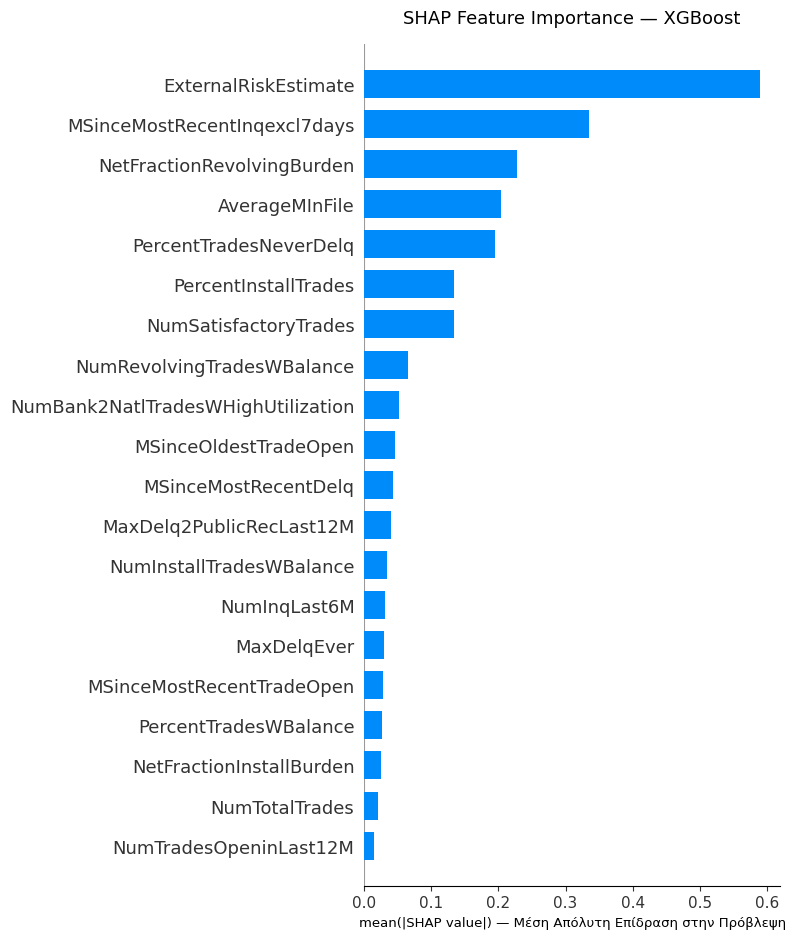

Αποθηκεύτηκε: figures/05_shap_feature_importance.png


In [23]:
os.makedirs('../figures', exist_ok=True)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, pad=15)
plt.xlabel('mean(|SHAP value|) — Μέση Απόλυτη Επίδραση στην Πρόβλεψη', fontsize=9.5)
plt.tight_layout()
plt.savefig('../figures/05_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/05_shap_feature_importance.png")

### 3.3 SHAP Summary Plot
Κατεύθυνση επίδρασης κάθε χαρακτηριστικού στην πρόβλεψη.

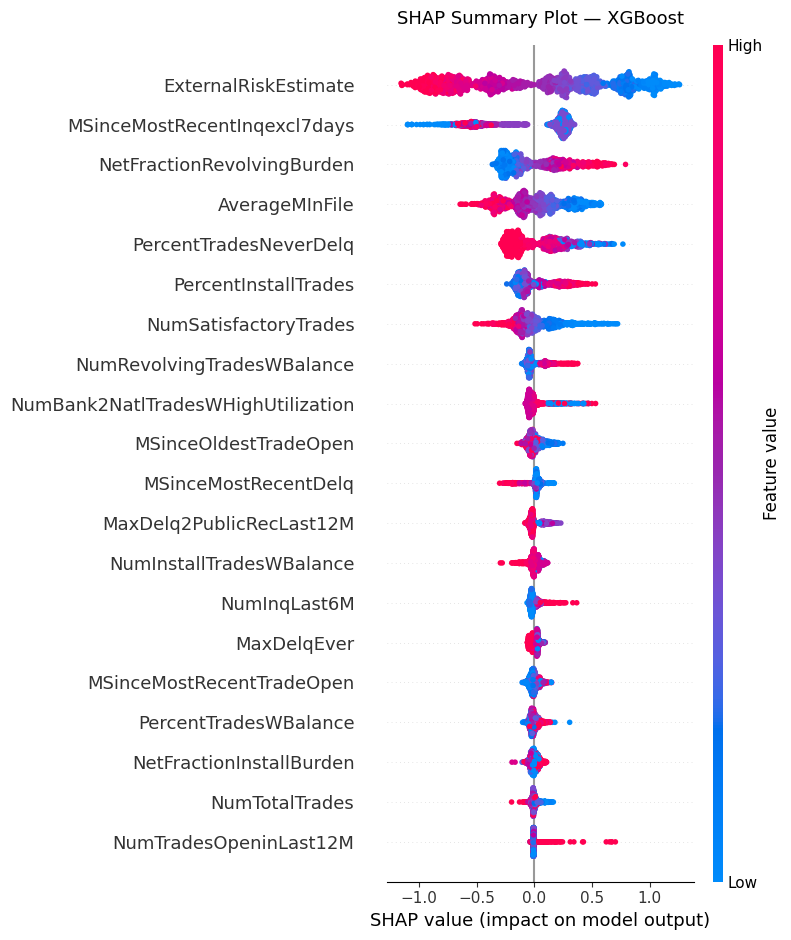

Αποθηκεύτηκε: figures/06_shap_summary.png


In [24]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot — XGBoost', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../figures/06_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/06_shap_summary.png")

### 3.4 Local Interpretability — Ανάλυση Μεμονωμένου Δανειολήπτη
Γιατί το μοντέλο έδωσε αυτή την απόφαση για έναν συγκεκριμένο δανειολήπτη;

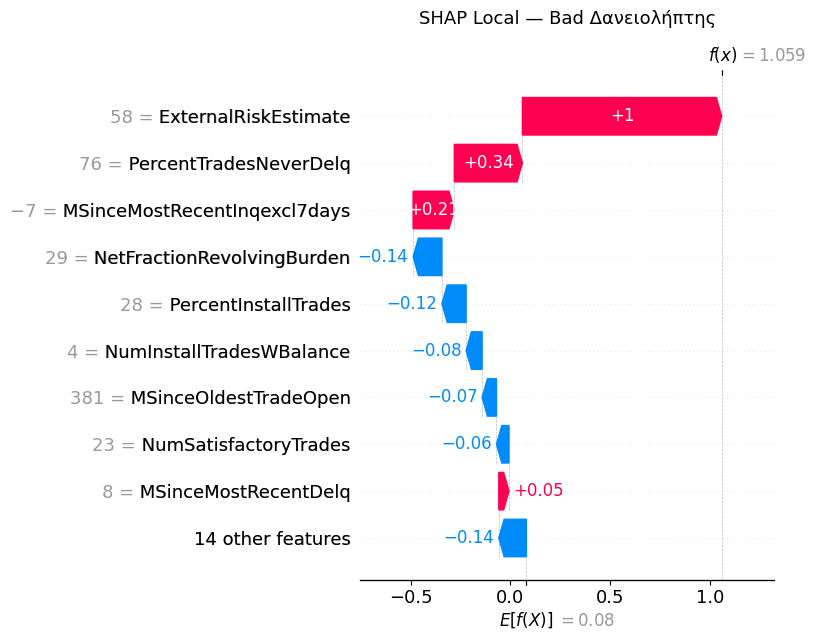

Αποθηκεύτηκε: figures/07_shap_local_bad.png


In [25]:
# Επιλογή ενός Bad και ενός Good δανειολήπτη
bad_idx  = np.where(y_test == 1)[0][0]
good_idx = np.where(y_test == 0)[0][0]

# Waterfall plot για Bad δανειολήπτη
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[bad_idx],
        base_values=explainer.expected_value,
        data=X_test[bad_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title('SHAP Local — Bad Δανειολήπτης', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../figures/07_shap_local_bad.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/07_shap_local_bad.png")

Good δανειολήπτης index: 1, prob: 0.157


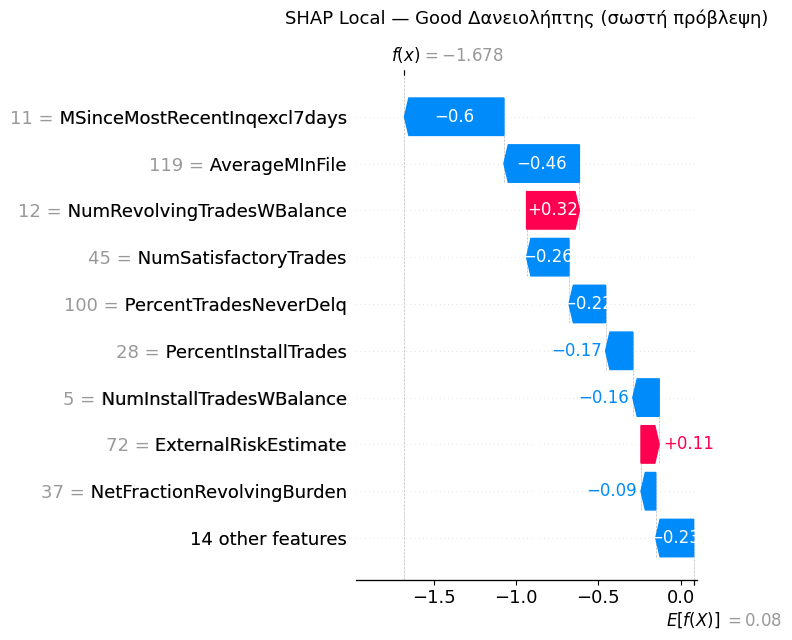

Αποθηκεύτηκε: figures/08_shap_local_good.png


In [26]:
# Εύρεση Good δανειολήπτη που το μοντέλο προβλέπει σωστά
xgb_prob_test = xgb_model.predict_proba(X_test)[:, 1]
good_correct = np.where((y_test == 0) & (xgb_prob_test < 0.4))[0]
good_idx = good_correct[0]
print(f"Good δανειολήπτης index: {good_idx}, prob: {xgb_prob_test[good_idx]:.3f}")

# Waterfall plot για σωστά ταξινομημένο Good δανειολήπτη
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[good_idx],
        base_values=explainer.expected_value,
        data=X_test[good_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title('SHAP Local — Good Δανειολήπτης (σωστή πρόβλεψη)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../figures/08_shap_local_good.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/08_shap_local_good.png")

### 3.5 Partial Dependence Plots (PDP)
Πώς επηρεάζει κάθε χαρακτηριστικό την πρόβλεψη όταν τα υπόλοιπα παραμένουν σταθερά;

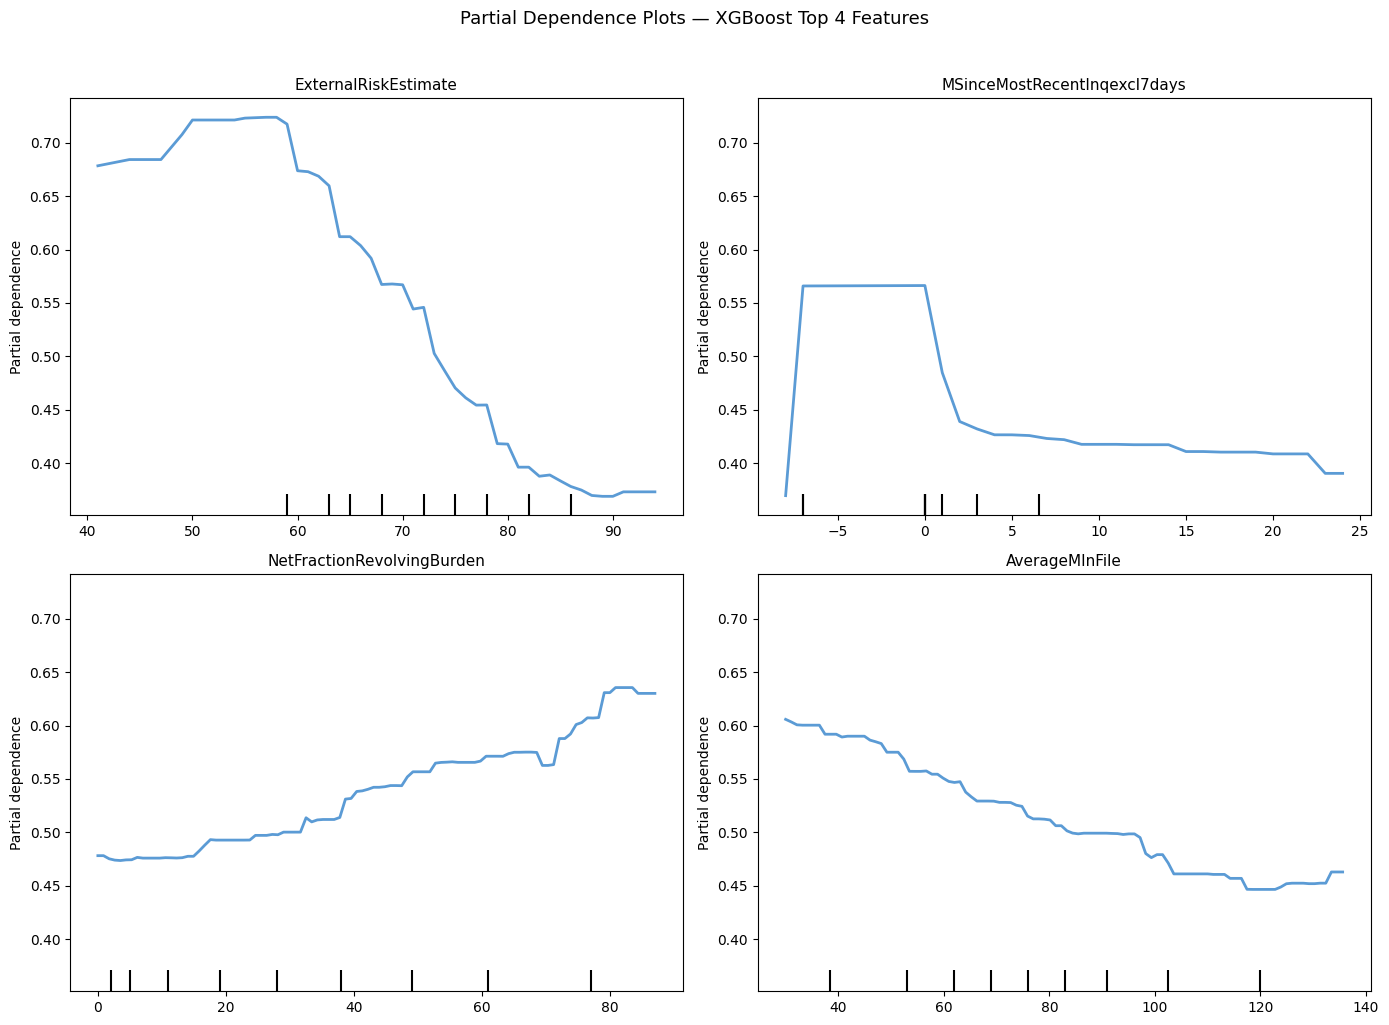

Αποθηκεύτηκε: figures/09_pdp.png


In [27]:
from sklearn.inspection import PartialDependenceDisplay

# PDP για τα 4 πιο σημαντικά features
top_features = ['ExternalRiskEstimate', 'MSinceMostRecentInqexcl7days', 
                'NetFractionRevolvingBurden', 'AverageMInFile']
top_idx = [list(feature_names).index(f) for f in top_features]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

PartialDependenceDisplay.from_estimator(
    xgb_model, X_test, top_idx,
    feature_names=feature_names,
    ax=axes,
    line_kw={'color': '#5b9bd5', 'linewidth': 2}
)

for i, ax in enumerate(axes):
    ax.set_title(top_features[i], fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Partial Dependence Plots — XGBoost Top 4 Features', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/09_pdp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/09_pdp.png")

## 4. SHAP Analysis — FFNN (Επιδεικτικός Ρόλος)
Επίδειξη της αυξημένης δυσκολίας ερμηνείας σε σχέση με το XGBoost.

In [28]:

# Για FFNN χρησιμοποιούμε KernelExplainer — πιο αργός αλλά model-agnostic

existing = glob.glob('../data/processed\shap_ffnn_values_*.npy')

# Με αυτή την if ελέγχω εάν υπάρχουν ήδη υπολογισμένα SHAP values για το FFNN, ώστε να μην χρειάζεται να τα υπολογίζω ξανά
# Τα αρχεία που έχω ήδη στον φάκελο έχουν προκύψει από προηγούμενη εκτέλεση του notebook της περίπτωσης else.
# Συγκεκριμένα για τα χαρακτηριστικά: background=500 samples από το X_train_scaled,
# sample=2000 πρώτες εγγραφές του X_test_scaled και nsamples=500 για την ακρίβεια του KernelExplainer.
# αρχείο ../data/processed\shap_ffnn_values_20260325_065734.npy

if existing:
    latest = sorted(existing)[-1]
    print(f"SHAP values βρέθηκαν — φόρτωση από: {latest}")
    shap_values_ffnn = np.load(latest)
    sample = np.load(latest.replace('values', 'sample'))
    print("Φόρτωση ολοκληρώθηκε.")
else:
    background = shap.sample(X_train_scaled, 500, random_state=42)
    sample = X_test_scaled[:2000]

    explainer_ffnn = shap.KernelExplainer(
        lambda x: ffnn_model.predict(x, verbose=0).flatten(),
        background
    )

    print("Υπολογισμός SHAP values για FFNN — εκτιμώμενος χρόνος: ~2.5 ώρες...")
    shap_values_ffnn = explainer_ffnn.shap_values(sample, nsamples=500)
    print("Ολοκληρώθηκε.")

    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    np.save(f'../data/processed/shap_ffnn_values_{ts}.npy', shap_values_ffnn)
    np.save(f'../data/processed/shap_ffnn_sample_{ts}.npy', sample)
    print(f"Αποθηκεύτηκε με timestamp: {ts}")

SHAP values βρέθηκαν — φόρτωση από: ../data/processed\shap_ffnn_values_20260325_065734.npy
Φόρτωση ολοκληρώθηκε.


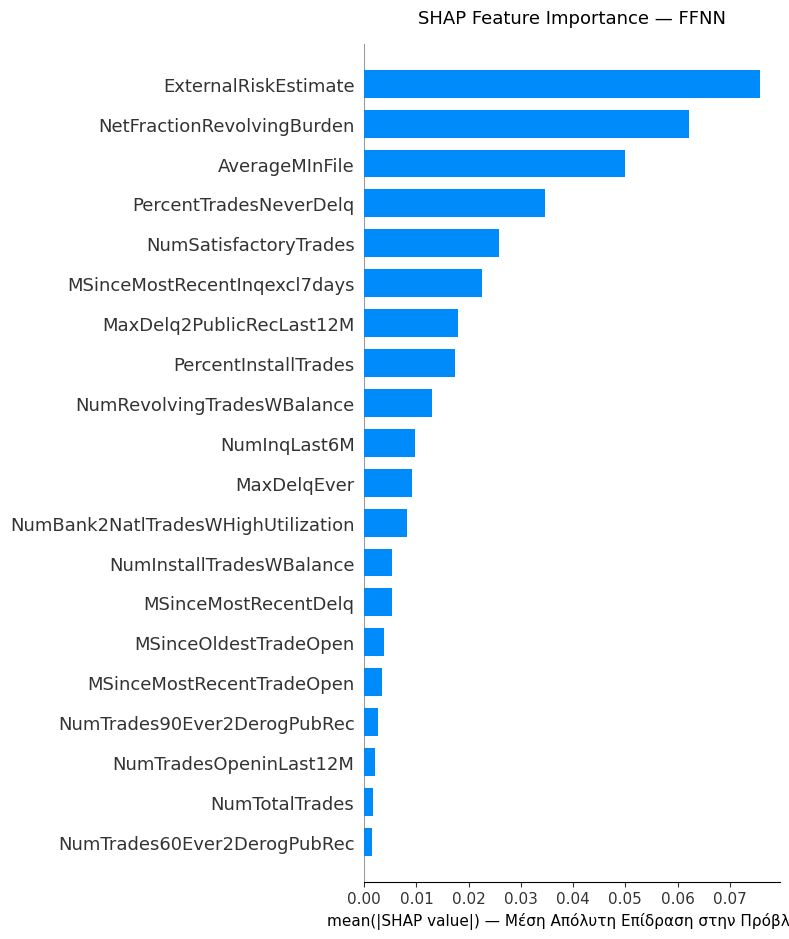

Αποθηκεύτηκε: figures/10_shap_ffnn_importance.png


In [29]:
# SHAP Feature Importance για FFNN
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_ffnn,
    sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — FFNN', fontsize=13, pad=15)
plt.xlabel('mean(|SHAP value|) — Μέση Απόλυτη Επίδραση στην Πρόβλεψη', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/10_shap_ffnn_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/10_shap_ffnn_importance.png")

## Σύγκριση Σύγκλισης KernelExplainer
Εξετάζουμε αν ο KernelExplainer παράγει σταθερή κατάταξη χαρακτηριστικών
με λιγότερα samples. Τρέχουμε τρεις διαμορφώσεις με αυξανόμενο υπολογιστικό
κόστος και συγκρίνουμε τα αποτελέσματα με την πλήρη εκτέλεση (2.5 ώρες).

In [30]:
import time

configurations = [
    {"label": "~2 λεπτά",   "background": 50,  "sample": 100, "nsamples": 50},
    {"label": "~10 λεπτά",  "background": 200, "sample": 300, "nsamples": 200},
]

results = {}

for cfg in configurations:
    print(f"Εκτέλεση: {cfg['label']} — background={cfg['background']}, "
          f"sample={cfg['sample']}, nsamples={cfg['nsamples']}")
    
    bg  = shap.sample(X_train_scaled, cfg["background"], random_state=42)
    smp = X_test_scaled[:cfg["sample"]]
    
    exp = shap.KernelExplainer(
        lambda x: ffnn_model.predict(x, verbose=0).flatten(),
        bg
    )
    
    t0 = time.time()
    vals = exp.shap_values(smp, nsamples=cfg["nsamples"])
    elapsed = (time.time() - t0) / 60
    
    importance = np.abs(vals).mean(axis=0)
    results[cfg["label"]] = {
        "importance": importance,
        "elapsed":    elapsed
    }
    print(f"  → Ολοκληρώθηκε σε {elapsed:.1f} λεπτά\n")

# Φόρτωση της πλήρους εκτέλεσης από τα αποθηκευμένα αρχεία
shap_values_full = np.load('../data/processed/shap_ffnn_values_20260325_065734.npy')

results["~2.5 ώρες"] = {
    "importance": np.abs(shap_values_full).mean(axis=0),
    "elapsed":    150.0
}

print("Όλες οι εκτελέσεις ολοκληρώθηκαν.")

Εκτέλεση: ~2 λεπτά — background=50, sample=100, nsamples=50


100%|██████████| 100/100 [00:15<00:00,  6.37it/s]
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  → Ολοκληρώθηκε σε 0.3 λεπτά

Εκτέλεση: ~10 λεπτά — background=200, sample=300, nsamples=200


100%|██████████| 300/300 [04:58<00:00,  1.01it/s]

  → Ολοκληρώθηκε σε 5.0 λεπτά

Όλες οι εκτελέσεις ολοκληρώθηκαν.


### Αποτελέσματα Σύγκρισης
Σύγκριση της κατάταξης των top-10 χαρακτηριστικών ανά διαμόρφωση.
Εάν η κατάταξη παραμένει σταθερή, ο μικρότερος υπολογιστικός χρόνος
είναι επαρκής για ερμηνευτικούς σκοπούς.

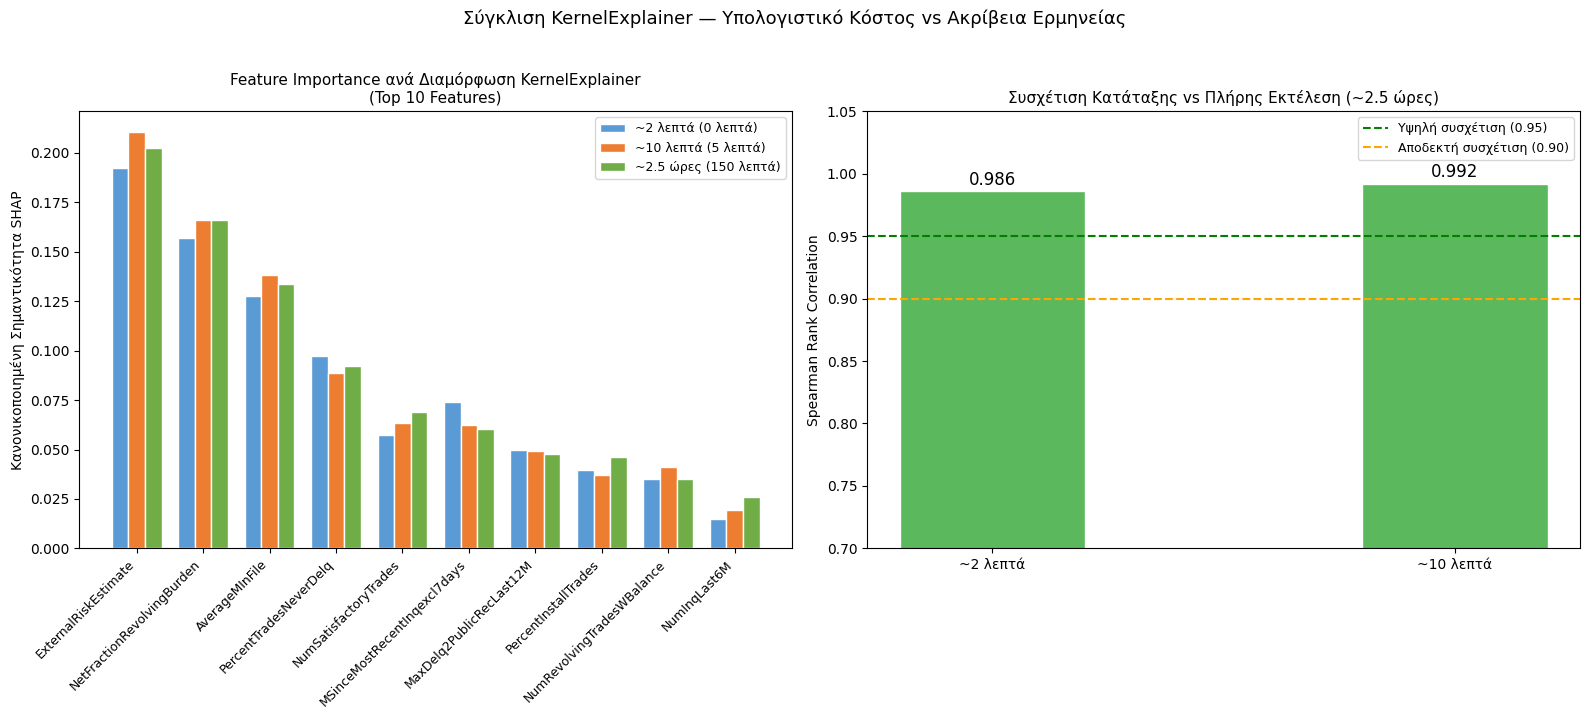

Αποθηκεύτηκε: figures/24_kernelexplainer_convergence.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# feature importance ανά configuration
# Βάση σύγκρισης: η σειρά από την πλήρη εκτέλεση
base_order = np.argsort(results["~2.5 ώρες"]["importance"])[::-1][:10]
top_features = [feature_names[i] for i in base_order]

colors = ["#5b9bd5", "#ed7d31", "#70ad47"]
x = np.arange(len(top_features))
width = 0.25

for idx, (label, data) in enumerate(results.items()):
    # Κανονικοποίηση ώστε να είναι συγκρίσιμα τα μεγέθη
    imp = data["importance"]
    imp_norm = imp / imp.sum()
    values = [imp_norm[i] for i in base_order]
    
    axes[0].bar(x + idx * width, values, width,
                label=f"{label} ({data['elapsed']:.0f} λεπτά)",
                color=colors[idx], edgecolor="white")

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(top_features, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("Κανονικοποιημένη Σημαντικότητα SHAP", fontsize=10)
axes[0].set_title("Feature Importance ανά Διαμόρφωση KernelExplainer\n(Top 10 Features)", fontsize=11)
axes[0].legend(fontsize=9)

# spearman rank correlation των importance rankings vs full run
from scipy.stats import spearmanr

base_importance = results["~2.5 ώρες"]["importance"]
labels_partial  = ["~2 λεπτά", "~10 λεπτά"]
correlations    = []
times           = []

for label in labels_partial:
    corr, _ = spearmanr(base_importance, results[label]["importance"])
    correlations.append(corr)
    times.append(results[label]["elapsed"])

bar_colors = ["#d9534f" if c < 0.9 else "#f0ad4e" if c < 0.95 else "#5cb85c"
              for c in correlations]

bars = axes[1].bar(labels_partial, correlations,
                   color=bar_colors, edgecolor="white", width=0.4)
axes[1].axhline(y=0.95, color="green",  linestyle="--",
                linewidth=1.5, label="Υψηλή συσχέτιση (0.95)")
axes[1].axhline(y=0.90, color="orange", linestyle="--",
                linewidth=1.5, label="Αποδεκτή συσχέτιση (0.90)")

for bar, val in zip(bars, correlations):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontsize=12)

axes[1].set_ylabel("Spearman Rank Correlation", fontsize=10)
axes[1].set_title("Συσχέτιση Κατάταξης vs Πλήρης Εκτέλεση (~2.5 ώρες)", fontsize=11)
axes[1].set_ylim(0.7, 1.05)
axes[1].legend(fontsize=9)

plt.suptitle("Σύγκλιση KernelExplainer — Υπολογιστικό Κόστος vs Ακρίβεια Ερμηνείας",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/24_kernelexplainer_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Αποθηκεύτηκε: figures/24_kernelexplainer_convergence.png")

# Σύγκριση Feature Importance XGBoost vs FFNN

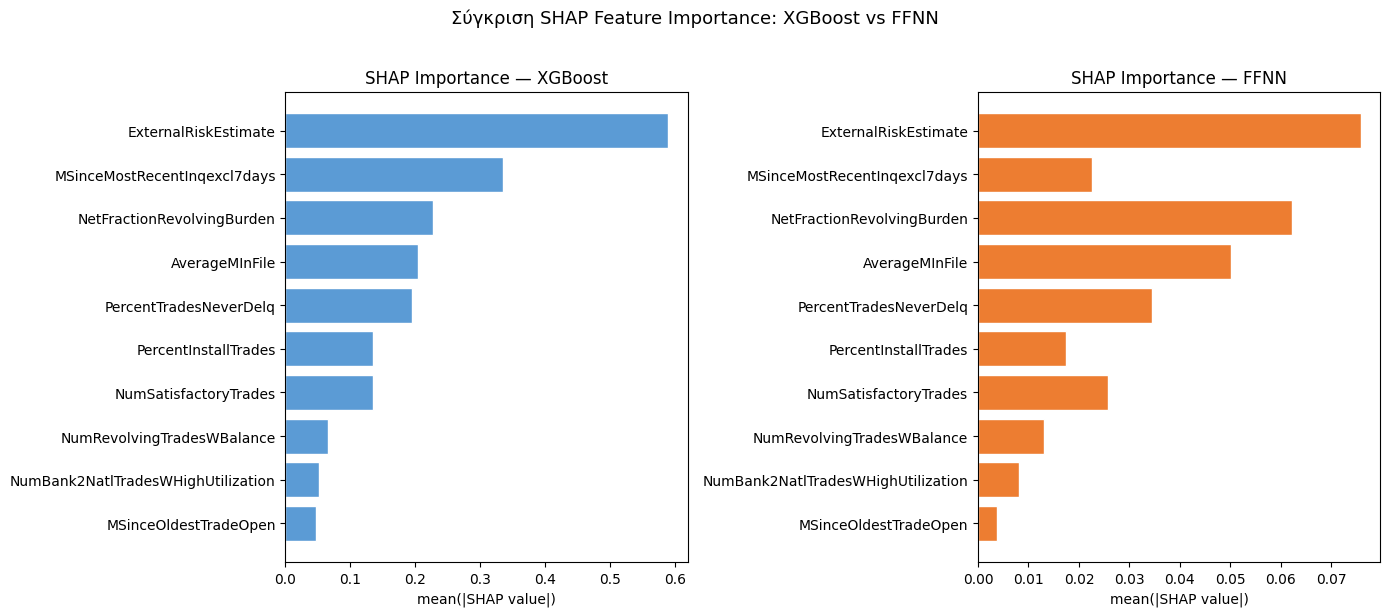

Αποθηκεύτηκε: figures/11_shap_comparison.png


In [32]:
shap_importance_xgb  = np.abs(shap_values).mean(axis=0)
shap_importance_ffnn = np.abs(shap_values_ffnn).mean(axis=0) # shap_values_ffnn είναι για την ανάλυση των 2,5 ωρών 

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': shap_importance_xgb,
    'FFNN': shap_importance_ffnn
}).sort_values('XGBoost', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#5b9bd5', '#ed7d31']

for i, (col, color) in enumerate(zip(['XGBoost', 'FFNN'], colors)):
    axes[i].barh(comparison_df['Feature'][::-1], 
                 comparison_df[col][::-1], 
                 color=color, edgecolor='white')
    axes[i].set_title(f'SHAP Importance — {col}', fontsize=12)
    axes[i].set_xlabel('mean(|SHAP value|)', fontsize=10)

plt.suptitle('Σύγκριση SHAP Feature Importance: XGBoost vs FFNN', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/11_shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/11_shap_comparison.png")

## 5. Score Distribution Plot
Κατανομή scores για Bad και Good δανειολήπτες ξεχωριστά.

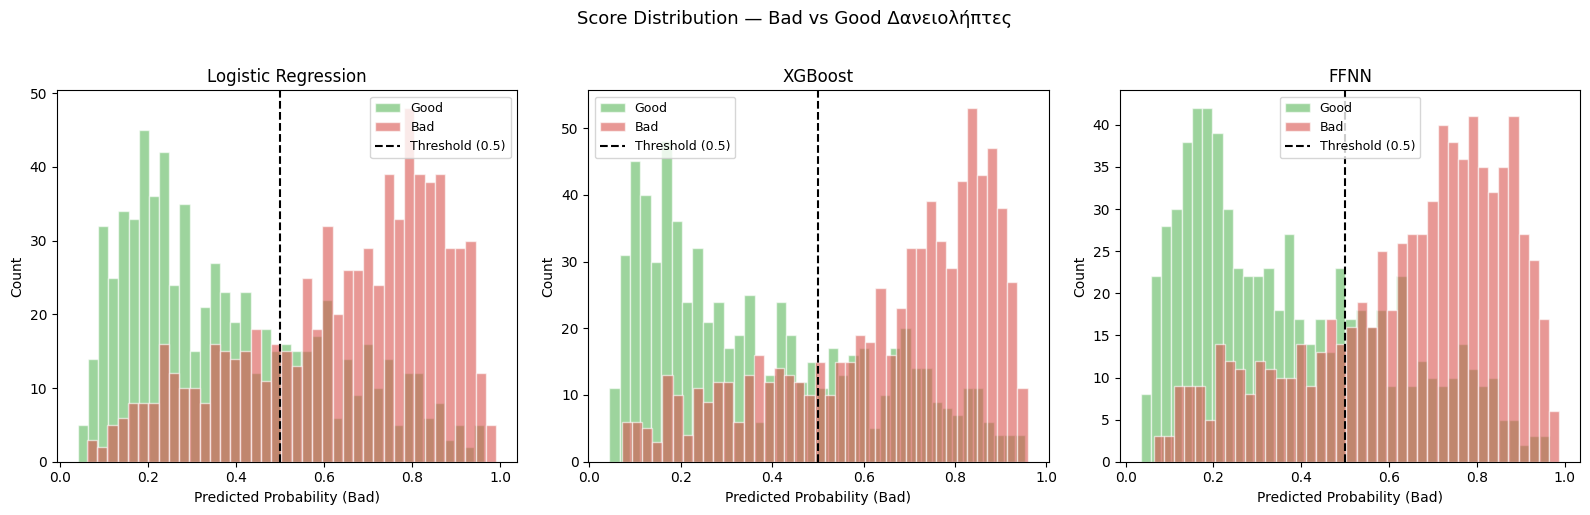

Αποθηκεύτηκε: figures/16_score_distribution.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_scores = [
    ('Logistic Regression', lr_model.predict_proba(X_test_scaled)[:, 1]),
    ('XGBoost', xgb_model.predict_proba(X_test)[:, 1]),
    ('FFNN', ffnn_model.predict(X_test_scaled, verbose=0).flatten())
]

for i, (name, scores) in enumerate(models_scores):
    axes[i].hist(scores[y_test==0], bins=40, alpha=0.6, 
                color='#5cb85c', label='Good', edgecolor='white')
    axes[i].hist(scores[y_test==1], bins=40, alpha=0.6,
                color='#d9534f', label='Bad', edgecolor='white')
    axes[i].axvline(x=0.5, color='black', linestyle='--', 
                   linewidth=1.5, label='Threshold (0.5)')
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel('Predicted Probability (Bad)', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(fontsize=9)

plt.suptitle('Score Distribution — Bad vs Good Δανειολήπτες', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/16_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/16_score_distribution.png")

## 7. Multiple Drift Scenarios
Σύγκριση PSI σε τρία σενάρια οικονομικής επιδείνωσης.

In [34]:
def calculate_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 1, bins + 1)
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 0.0001, actual_pct)
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

scores_now = xgb_model.predict_proba(X_test)[:, 1]

scenarios = {
    'Ήπια επιδείνωση': (0.2, 0.2, 0.15),
    'Μέτρια επιδείνωση': (0.5, 0.5, 0.4),
    'Σοβαρή επιδείνωση': (0.9, 0.9, 0.7)
}

ext_idx = list(feature_names).index('ExternalRiskEstimate')
net_idx = list(feature_names).index('NetFractionRevolvingBurden')
avg_idx = list(feature_names).index('AverageMInFile')

psi_results = []

for scenario_name, (ext_factor, net_factor, avg_factor) in scenarios.items():
    np.random.seed(42)
    X_scenario = X_test.copy().astype(float)
    
    for i, feature in enumerate(feature_names):
        std = X_test[:, i].std()
        if feature == 'ExternalRiskEstimate':
            X_scenario[:, i] += np.random.normal(-ext_factor * std, 0.15 * std, size=len(X_scenario))
        elif feature == 'NetFractionRevolvingBurden':
            X_scenario[:, i] += np.random.normal(net_factor * std, 0.15 * std, size=len(X_scenario))
        elif feature == 'AverageMInFile':
            X_scenario[:, i] += np.random.normal(-avg_factor * std, 0.15 * std, size=len(X_scenario))
        else:
            X_scenario[:, i] += np.random.normal(0, 0.1 * std, size=len(X_scenario))
    
    scores_scenario = xgb_model.predict_proba(X_scenario)[:, 1]
    psi_scenario = calculate_psi(scores_now, scores_scenario)
    psi_results.append({'Σενάριο': scenario_name, 'PSI': psi_scenario})
    print(f"{scenario_name}: PSI = {psi_scenario:.4f}")

print()
print("Baseline (κανένα drift): PSI = 0.0000")

Ήπια επιδείνωση: PSI = 0.0685
Μέτρια επιδείνωση: PSI = 0.2099
Σοβαρή επιδείνωση: PSI = 0.6410

Baseline (κανένα drift): PSI = 0.0000


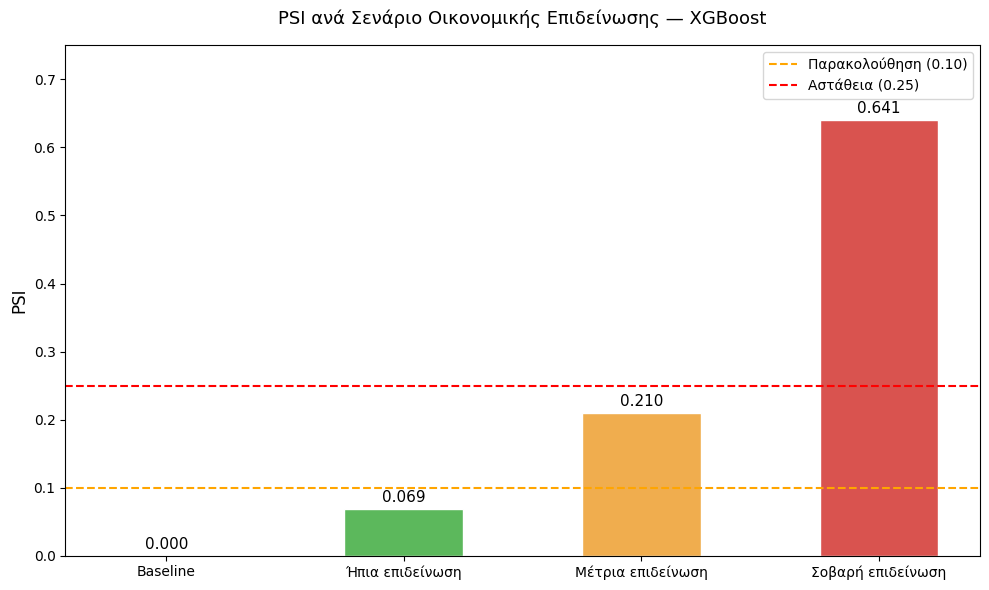

Αποθηκεύτηκε: figures/17_psi_scenarios.png


In [35]:
psi_df = pd.DataFrame(psi_results)
psi_df = pd.concat([
    pd.DataFrame([{'Σενάριο': 'Baseline', 'PSI': 0.0}]),
    psi_df
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#5cb85c' if x < 0.10 else '#f0ad4e' if x < 0.25 else '#d9534f' 
          for x in psi_df['PSI']]

bars = ax.bar(psi_df['Σενάριο'], psi_df['PSI'], 
              color=colors, edgecolor='white', width=0.5)

ax.axhline(y=0.10, color='orange', linestyle='--', 
           linewidth=1.5, label='Παρακολούθηση (0.10)')
ax.axhline(y=0.25, color='red', linestyle='--', 
           linewidth=1.5, label='Αστάθεια (0.25)')

for bar, val in zip(bars, psi_df['PSI']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11)

ax.set_ylabel('PSI', fontsize=12)
ax.set_title('PSI ανά Σενάριο Οικονομικής Επιδείνωσης — XGBoost', 
             fontsize=13, pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.savefig('../figures/17_psi_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/17_psi_scenarios.png")